<center><img src="images/logo.png" alt="drawing" width="400" style="background-color:white; padding:1em;" /></center> <br/>

# Application of Deep Learning to Text and Images
## Module 3, Lab 1: Reading image data to find descriptors and create plots

This notebook will show you how to open and read image data using Python and PyTorch, extract features from images and you will learn how to plot images.

You will learn the following:

- How to import image data
- How to extract features from image data
- How to plot image data

----

You will be presented withz challenges throughout the notebook: <br/>

| <img style="float: center;" src="images/challenge.png" alt="Challenge" width="125"/>|
| --- |
|<p style="text-align:center;">Challenges are where you can practice your coding skills.</p>


## Index

- [Reading Images](#Reading-Images)
- [Inspecting Images](#Inspecting-Images)
- [Extracting Features](#Extracting-Features)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
import os

# List files in the current directory
files = !ls

# If the file is not in the current directory, you need to find its path
if 'MLUDTI_EN_M3_Lab1_quiz_questions.py' not in files:
    module_path = os.path.abspath(os.path.join('/content/drive/MyDrive/Colab Notebooks/CCC/Deep Learning'))
    if module_path not in sys.path:
        sys.path.append(module_path)


# Import utility functions that provide answers to challenges
from MLUDTI_EN_M3_Lab1_quiz_questions import *

Mounted at /content/drive


In [2]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

import torch
from torch import nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset

import sys

sys.path.insert(1, "..")

## Reading Images
In this section you are going to learn how to open images using Python and how to inspect those images.

### PyTorch Image Datasets

First, load the CIFAR10 data. This is one of many image datasets that can be loaded in directly with `torchvision`. It has the classes: ‘airplane’, ‘automobile’, ‘bird’, ‘cat’, ‘deer’, ‘dog’, ‘frog’, ‘horse’, ‘ship’, ‘truck’. The images in CIFAR-10 are of size 3x32x32, i.e. 3-channel color images of 32x32 pixels in size.

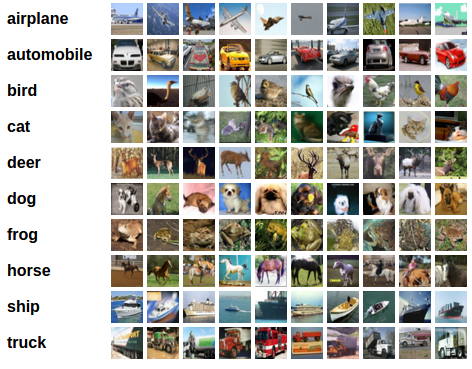



In [3]:
%%capture

# Get the training images
img_train = torchvision.datasets.CIFAR10(
    root="data",
    download=True,
    train=True,
    transform=transforms.ToTensor(),
)

# Get the test images
img_test = torchvision.datasets.CIFAR10(
    root="data",
    download=True,
    train=False,
    transform=transforms.ToTensor(),
)

In [4]:
img_train.data.shape

(50000, 32, 32, 3)

In [5]:

myset = set(img_train.targets)
print(myset)

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}


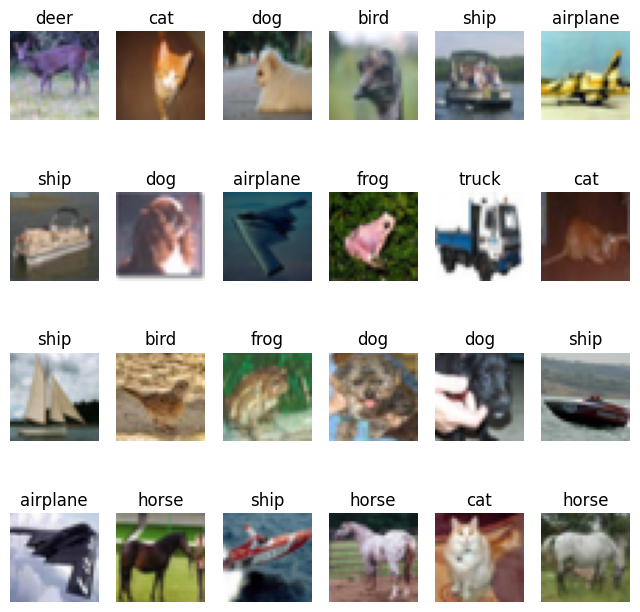

In [6]:
from random import randrange
cols = 6
rows = 4
fig, axs = plt.subplots(rows, cols, figsize=(8, 8))
IDX_TO_LABEL = {v: k for k, v in img_train.class_to_idx.items()}
for x in range(rows):
    for y in range(cols):
        rnd_idx = randrange(len(img_train.data))

        axs[x, y].set_title(IDX_TO_LABEL[img_train.targets[rnd_idx]])
        axs[x, y].imshow(img_train.data[rnd_idx])
        axs[x, y].set_axis_off()

plt.show()

In [7]:
IDX_TO_LABEL

{0: 'airplane',
 1: 'automobile',
 2: 'bird',
 3: 'cat',
 4: 'deer',
 5: 'dog',
 6: 'frog',
 7: 'horse',
 8: 'ship',
 9: 'truck'}

### Inspecting an Image

You can look at one example data point by specifying the ID of the image you want to retrieve. As result, you get a tuple of `(image, label)`. If you call `image.shape` you can see how many color channels the image contains, the height, and width: `[color channels, height, width]`.

In [8]:
# Print the image and label at the 42nd index
image, label = img_train[42]
print(image.shape, "Label: ",label)

torch.Size([3, 32, 32]) Label:  2


The output above tells you 4 things:
1. This is a color image with __3__ channels.
1. The height of the image is __32__ px.
1. The width of the image is __32__ px.
1. Time image lable is __2__.

### Images as Tensors

PyTorch has a constructor that creates a `Dataset` object from a list of tensors similar to what you saw above:

`torch.utils.data.TensorDataset`

This is simply a tensor data construct that allows you to access individual images (or batches of images) and their labels easily.

To create a TensorDataset you need to pass the images (data_tensor) and labels (target_tensor) into `Dataloader`.

In [9]:
# Take the first 50 example images from the training
# dataset and their corresponding labels

data_tensor = torch.Tensor(img_train.data[:50])
target_tensor = torch.Tensor(img_train.targets[:50])

tensor_dataset = TensorDataset(data_tensor, target_tensor)

print(tensor_dataset)

### Loading an Image Dataset

Now that you have created a PyTorch tensor dataset, you need to learn what you can do with it. The first question is, how can you access individual or multiple images in the tensor dataset?

Images can be accessed using a dataloader. `torch.utils.data.DataLoader` takes a `TensorDataset` object as input, and allows you to iterate through minibatches of your data.

`torch.utils.data.DataLoader` has arguments such as:

* `batch_size` - sets the batch size
* `shuffle` - boolean that determines whether to vend the data in a random order, or iterate in order
* `drop_last` - set to True to drop the last incomplete batch, if the dataset size is not divisible by the batch size. If False and the size of dataset is not divisible by the batch size, then the last batch might be smaller. This can be helpful if your models requires batches to be exactly the same size for each iteration.

Now, use the tensor dataset you created with 50 example images with a `DataLoader` to create batches of `32` images from the CIFAR10 data.

In [10]:
dataloader = torch.utils.data.DataLoader(
    tensor_dataset, batch_size=32, shuffle=True, drop_last=False
)

In [11]:
for data, labels in dataloader:
    print(data.shape)

torch.Size([32, 32, 32, 3])
torch.Size([18, 32, 32, 3])


<div style="border: 4px solid coral; text-align: center; margin: auto;">
    <h3><i>It's time to check your knowledge!</i></h3>
    <br>
    <p style=" text-align: center; margin: auto;">To load the question, run the following cell.</p>
    <br>
</div>

In [12]:
question_1

<div style="border: 4px solid coral; text-align: center; margin: auto;">
    <h2><i>Try it Yourself!</i></h2>
    <br>
    <img style="float: center;" src="images/challenge.png" alt="Challenge" width="100" />
    <p style="text-align: center; margin: auto;">Update the <code>DataLoader</code> code and set <code>drop_last=True</code>. </p>
    <p style="text-align: center; margin: auto;">How many batches do you think will be created? Check your answer</p>
</div>

DataLoader is a fundamental part of PyTorch and is used for loading a dataset for training or inference, allowing for easy and efficient batching, shuffling, and parallel loading using multiple worker processes.

Here's a breakdown of the code and its parameters:

**dataloader**: This is the variable name assigned to the DataLoader instance being created. This DataLoader object will be used to iterate over the dataset during the training or evaluation of a model.

**torch.utils.data.DataLoader**: This is the constructor for creating a DataLoader object. The DataLoader wraps a dataset and provides an iterable over the dataset.

Parameters of DataLoader:

**tensor_dataset:** This is the dataset to be loaded by the DataLoader. The dataset should be an instance of a subclass of torch.utils.data.Dataset. In this case, tensor_dataset likely contains tensors representing your data and targets. It's not defined in this line but should be defined elsewhere in your code.

**batch_size=32**: This specifies the number of data samples to load in each batch. A batch size of 32 means that each batch returned by the DataLoader will contain 32 samples from tensor_dataset. This is a common batch size, balancing computational efficiency and the ability to generalize across different samples.

**shuffle=True**: This parameter controls whether the data should be shuffled at the beginning of each epoch. Setting shuffle=True is useful for training models because it reduces the likelihood of the model learning patterns from the order of the data rather than the data itself. It's common practice to shuffle the training data but not the validation or test data.

**drop_last=True**: This determines whether to drop the last incomplete batch if the dataset size is not divisible by the batch size. When drop_last=True, if there are not enough samples left for a full batch, that last partial batch will not be used. This can be useful when the exact number of batches per epoch is important, such as when using batch normalization, which may not work well with small batches.

In [13]:
# Create a dataloader that drops incomplete batches and
# print the data shapes for each batch
########## CODE HERE ###############
dataloader = torch.utils.data.DataLoader(
    tensor_dataset, batch_size=32, shuffle=True, drop_last=True
)
# creates a DataLoader that will iterate over tensor_dataset in batches of 32 samples,
# shuffling the order of the data at the beginning of each epoch, and dropping the last batch if it's not full.
for data, labels in dataloader:
    print(data.shape)


########## END OF CODE ##########

torch.Size([32, 32, 32, 3])


## Inspecting Images

Now that you have loaded the images and created batches you are ready to inspect the images. This next section will show you how to separate images into different color channels.

image.permute(1, 2, 0): This part of the code is a tensor manipulation operation that comes from PyTorch, a deep learning framework. The permute method rearranges the dimensions of a tensor according to the specified order. The image variable is assumed to be a tensor representing an image.

In the context of PyTorch, images are typically represented as tensors of shape (C, H, W), where C is the number of channels (e.g., 3 for RGB images), H is the height, and W is the width of the image.
The permute(1, 2, 0) operation changes the order of these dimensions to (H, W, C). This is necessary because plt.imshow() expects the image array to be in the format (H, W, C) or (H, W) (for grayscale images). It rearranges the tensor so that the channel dimension comes last, matching the input format that plt.imshow() expects.

[[[0.49803922 0.5803922  0.7529412  ... 0.4392157  0.5647059  0.6       ]
  [0.34901962 0.43529412 0.5921569  ... 0.6313726  0.6509804  0.6392157 ]
  [0.38431373 0.36862746 0.43137255 ... 0.6784314  0.6627451  0.6784314 ]
  ...
  [0.6117647  0.5921569  0.58431375 ... 0.5882353  0.58431375 0.5568628 ]
  [0.6392157  0.63529414 0.6313726  ... 0.5294118  0.5529412  0.5411765 ]
  [0.627451   0.627451   0.6392157  ... 0.5411765  0.56078434 0.5921569 ]]

 [[0.49411765 0.5647059  0.70980394 ... 0.4        0.5294118  0.5568628 ]
  [0.3529412  0.43137255 0.5529412  ... 0.59607846 0.61960787 0.6039216 ]
  [0.36862746 0.36862746 0.42745098 ... 0.62352943 0.6039216  0.6156863 ]
  ...
  [0.59607846 0.5686275  0.5647059  ... 0.5647059  0.5803922  0.56078434]
  [0.61960787 0.60784316 0.5921569  ... 0.5137255  0.5372549  0.5254902 ]
  [0.59607846 0.5921569  0.6        ... 0.4745098  0.5137255  0.5294118 ]]

 [[0.5058824  0.5647059  0.6862745  ... 0.38431373 0.48235294 0.50980395]
  [0.36862746 0.454901

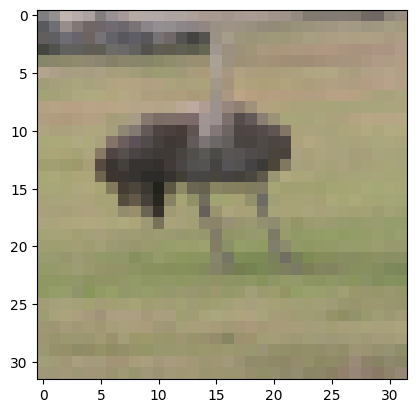

In [17]:
# You can convert from an an image object to an array using np.asarray
# to be able to look at the pixel values and manipulate them
img_array = np.asarray(image)
# Print the pixel values
print(img_array)

# Given the tensor representing the image,
# use .permute() to put the channels as the last dimension:
plt.imshow(image.permute(1, 2, 0))

green[:, :, 0] = 0 and green[:, :, 2] = 0:

These lines set the red and blue channels of the image to 0, leaving only the green channel. In an RGB image, the channels are indexed as 0 (red), 1 (green), and 2 (blue). By setting the red and blue channels to 0 across all pixels (: indicates all elements along that dimension), only the green channel's values are retained, effectively filtering the image to show only the green component.

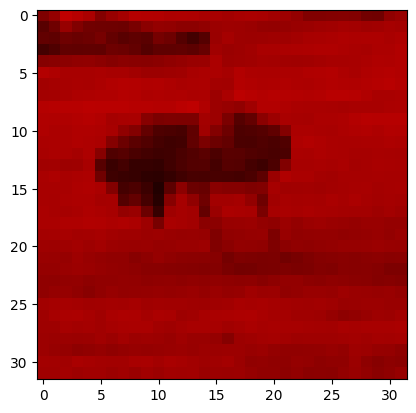

In [18]:
# Check that the color ordering matches what is expect (RGB)

# Zeroing out channels 1 and 2 should show the red color channel
# Note: Remember that Python uses 0 index so the red channel is number 0
red = image.permute(1, 2, 0).detach().clone()

red[:, :, 1] = 0
red[:, :, 2] = 0
plt.imshow(red)

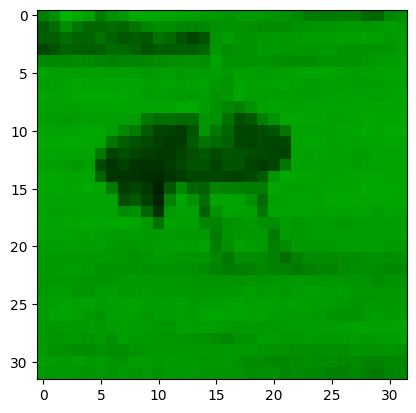

In [38]:
# Zero out channels 0 and 2 to see an image with green hues

green = image.permute(1, 2, 0).detach().clone()

green[:, :, 0] = 0
green[:, :, 2] = 0

plt.imshow(green)

<div style="border: 4px solid coral; text-align: center; margin: auto;">
    <h2><i>Try it Yourself!</i></h2>
    <br>
    <img style="float: center;" src="images/challenge.png" alt="Challenge" width="100" />
    <p style="text-align: center; margin: auto;">Print an image with only blue hues.
</div>

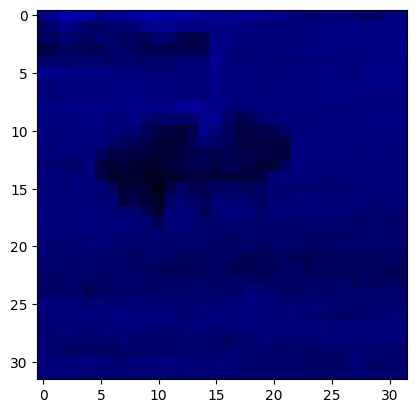

In [39]:
# Zero out the correct channels to see an image with blue hues
########## CODE HERE ###############
blue = image.permute(1, 2, 0).detach().clone()

blue[:, :, 0] = 0
blue[:, :, 1] = 0

plt.imshow(blue);


########## END OF CODE ##########

## Extracting Features

The next step is to learn how to extract features from the image. You can do this by applying a convolutional layer and a Laplace filter. The Laplacian of an image highlights regions of rapid intensity change and is therefore often used for edge detection.

in_channels=3: This specifies the number of input channels that the convolutional layer expects. For an RGB image, this would be 3, corresponding to the red, green, and blue channels.

out_channels=1: This determines the number of output channels produced by the convolution. Setting this to 1 means that the layer will produce a single output channel. This could be used, for example, to generate a grayscale output from an RGB input or to apply a specific filter that condenses input information into a single channel.

kernel_size=3: The size of the filter or kernel to apply to the input. A kernel_size of 3 means that the convolution will use a 3x3 filter. The kernel slides over the input image spatial dimensions (width and height), computing a weighted sum of the input pixel values within its receptive field. This size affects the level of detail the layer can capture, with smaller kernels capturing finer details.

padding=1: Padding adds layers of zeros around the input tensor. A padding of 1 means that a single row/column of zeros will be added to each side of the input. This is often used to control the spatial dimensions of the output tensor. With a kernel size of 3 and padding of 1, the output tensor will have the same height and width as the input tensor if the stride is 1 (stride is the step size the kernel moves each time, defaulting to 1 if not specified).

bias=False: This indicates that the layer will not use bias parameters in its computations. In many layers, a bias is added to the output of the weight sum before applying the activation function. Setting bias=False omits this bias term, which can be desirable in certain architectures or when the subsequent layer (e.g., batch normalization) makes the bias unnecessary.



In [40]:
# Initialize a convolutional layer using PyTorch
conv2d = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3, padding=1, bias=False)

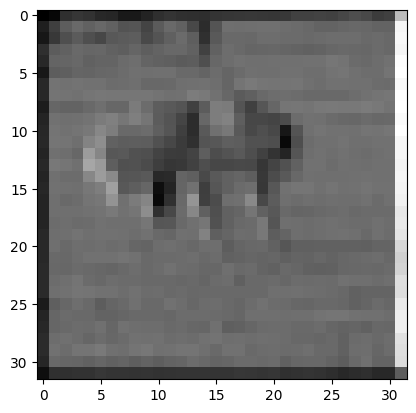

In [41]:
# Plot the resulting feature map as a grayscale image
plt.imshow(conv2d(image).permute(1, 2, 0).detach().numpy(), cmap="gray")

In digital image processing, we use a Laplacian filter to compute the second-order derivative of an image to detect edges. We need a Laplacian filter so that we can extract the features of the image in a better way. The better we can extract the features of the image, the better we will make the model to train.

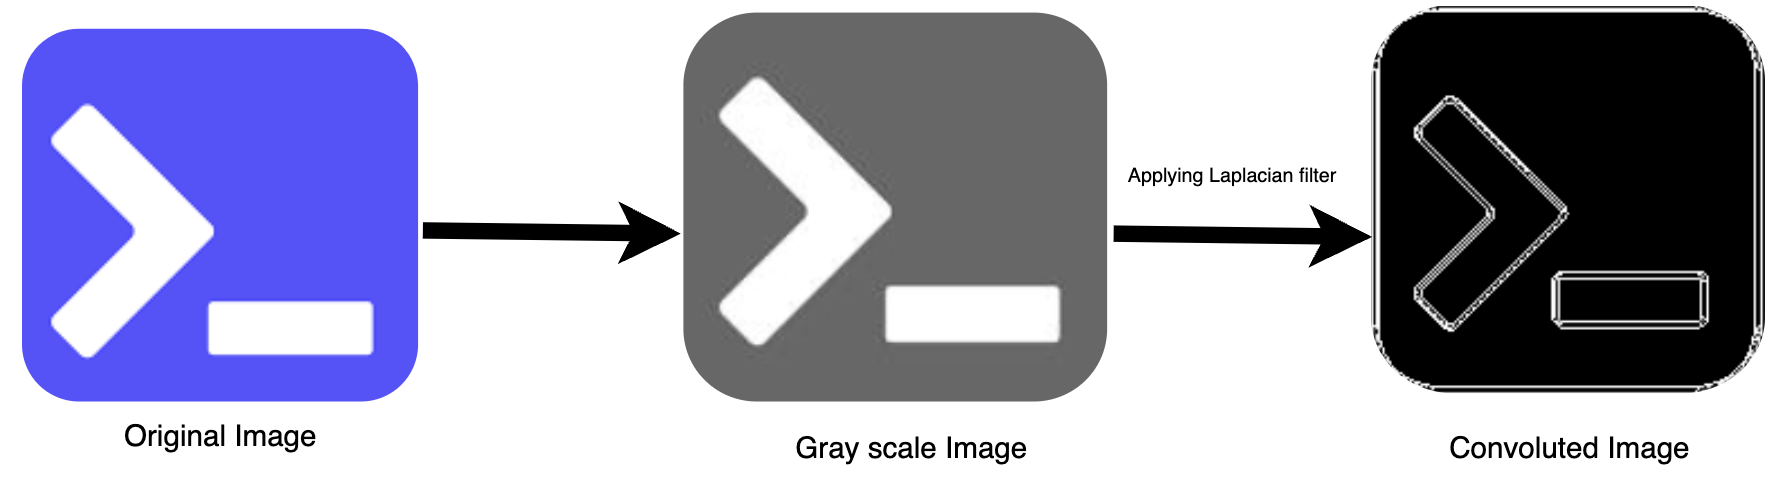

laplace = torch.Tensor([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]]):

This line creates a 2D tensor representing a 3x3 Laplace filter. The Laplace filter is used for edge detection in images. The central value (8) highlights the center pixel, while the surrounding values (-1) are used to subtract the neighboring pixel values, emphasizing edges in the processed image.

laplace_kernel = torch.stack((laplace, laplace, laplace), dim=0).unsqueeze(0):

This line stacks three copies of the Laplace filter tensor along a new dimension at the beginning (dim=0), creating a 3D tensor. This is because convolutional layers in PyTorch expect the weight tensor to have a shape of [out_channels, in_channels, height, width]. Since the Laplace filter will be applied to an image with 3 channels (e.g., RGB), we stack three copies of the filter to create a tensor suitable for each input channel. The unsqueeze(0) call then adds an extra dimension at the beginning, preparing the tensor to have the right shape as convolutional kernel weights ([out_channels, in_channels, height, width]), with out_channels set to 1 here.

laplace_conv2d = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3, padding=1, bias=False):

This line initializes a 2D convolutional layer using PyTorch's nn.Conv2d class. The in_channels=3 argument specifies that the input image has 3 channels (e.g., RGB). out_channels=1 means the output of the convolution will have 1 channel. kernel_size=3 sets the size of the convolutional kernel to 3x3, matching the Laplace filter size. padding=1 ensures the output image has the same height and width as the input image by adding padding around the edges. bias=False indicates that no bias term will be added to the output of the convolution.

laplace_conv2d.weight.data = laplace_kernel:

This line sets the weights of the convolutional layer to the previously defined Laplace kernel. This effectively replaces the random initial weights of the nn.Conv2d layer with the specific values designed for edge detection.

laplace_conv2d.weight.requires_grad = False:

This line disables gradient computation for the weights of the convolutional layer. Since the Laplace filter is a fixed operator for edge detection, we do not want these weights to be updated during any training process. Setting requires_grad to False ensures that these weights are treated as constants and not variables to be optimized during training.

In [42]:
# Use nn.Conv2d to apply a 3x3 Laplace filter to the image
laplace = torch.Tensor([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])
laplace_kernel = torch.stack((laplace, laplace, laplace), dim=0).unsqueeze(0)

# Set weights of convolutional layer to the Laplace kernel
laplace_conv2d = nn.Conv2d(
    in_channels=3, out_channels=1, kernel_size=3, padding=1, bias=False
)
laplace_conv2d.weight.data = laplace_kernel
laplace_conv2d.weight.requires_grad = False

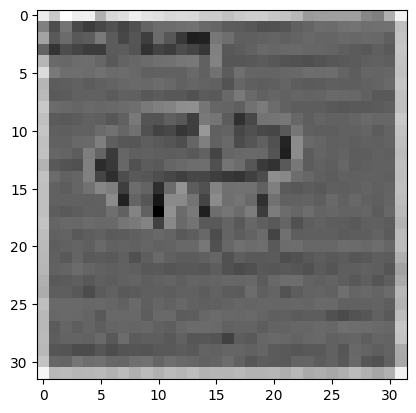

In [43]:
# Plot the resulting feature map as a grayscale image
plt.imshow(laplace_conv2d(image).permute(1, 2, 0).detach().numpy(), cmap="gray")

<div style="border: 4px solid coral; text-align: center; margin: auto;">
    <h3><i>It's time to check your knowledge!</i></h3>
    <br>
    <p style=" text-align: center; margin: auto;">To load the question, run the following cell.</p>
    <br>
</div>

In [44]:
question_2

<div style="border: 4px solid coral; text-align: center; margin: auto;">
    <h2><i>Try it Yourself!</i></h2>
    <br>
    <img style="float: center;" src="images/challenge.png" alt="Challenge" width="100" />
    <p style="text-align: center; margin: auto;">Try to create a new filter using a sharpening kernel:
\begin{bmatrix}
\ \ 0 & -1 & \ \ 0 \\
-1 & \ \ 5 & -1 \\
\ \ 0 & -1 & \ \ 0
\end{bmatrix}
.
</div>

sharpening = torch.Tensor([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])

Define the Sharpening Kernel: A sharpening kernel (also known as a filter) is defined as a 2D Tensor. This particular kernel is a common choice for enhancing edges within an image, making the image appear sharper by emphasizing differences in adjacent pixel values.

sharpening_kernel = torch.stack((sharpening, sharpening, sharpening), dim=0).unsqueeze(0)


Stack and Format the Kernel: Since images will typically have three color channels (RGB), the kernel is stacked three times and unsqueezed to match the expected dimensions of nn.Conv2d's weight parameter (out_channels, in_channels, height, width). This ensures the kernel is applied to each color channel independently.

sharpening_conv2d = nn.Conv2d(
    in_channels=3, out_channels=1, kernel_size=3, padding=1, bias=False
)

Initialize and Configure nn.Conv2d: A 2D convolutional layer is created with in_channels=3 and out_channels=1, meaning it takes a 3-channel image as input and produces a single-channel (grayscale) image as output. The kernel size is set to 3 (matching the sharpening kernel's dimensions), and padding is set to 1 to preserve the input image's spatial dimensions. The bias is disabled (bias=False) since it's not necessary for the sharpening process

sharpening_conv2d.weight.data = sharpening_kernel
sharpening_conv2d.weight.requires_grad = False

Set the Weights of the Convolutional Layer: The weights of the convolutional layer are manually set to the previously defined sharpening kernel, and gradients are disabled for these weights (requires_grad = False) because they shouldn't change during any training process (if applicable). This step effectively hardcodes the convolutional layer to only perform the sharpening operation.



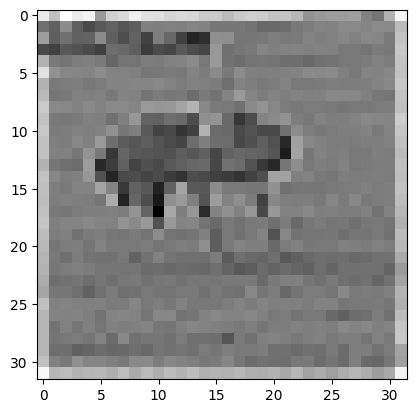

In [45]:
# Create a tensor that holds the sharpening kernel
# Then set the weights of the convolutional to use the sharpening kernel
########## CODE HERE ###############
### Use nn.Conv2d to apply a 3x3 sharpening filter to the image
sharpening = torch.Tensor([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpening_kernel = torch.stack((sharpening, sharpening, sharpening), dim=0).unsqueeze(0)

# Set weights of the convolutional layer to the sharpening kernel
sharpening_conv2d = nn.Conv2d(
    in_channels=3, out_channels=1, kernel_size=3, padding=1, bias=False
)
sharpening_conv2d.weight.data = sharpening_kernel
sharpening_conv2d.weight.requires_grad = False

# Plot the resulting feature map as a grayscale image
plt.imshow(sharpening_conv2d(image).permute(1, 2, 0).detach().numpy(), cmap="gray");

########## END OF CODE ##########

Every kernel will have a different impact on the image. The Laplace and sharpening kernels are well know and commonly used, but there are many others you can try to enhance the data.

----
## Conclusion

This notebook is meant to be a quick way to get you up-to-speed with loading images, creating `TensorDatasets` and extracting features from images using simple filters.

---
## Next Lab: The concept of convolution
In the next lab, you will learn how to build a Convolutional Neural Network (CNN) by using built-in CNN architectures in [PyTorch](https://pytorch.org/docs/stable/index.html) to train a multiclass classification model on a real-world dataset.